# Splitting the MGI ATAC reads for Cell Ranger ARC

Notebook 01 established what Cell Ranger ARC expects. This notebook deals with the one place
where the newt data genuinely does not conform, and builds the fix.

**The problem in one line:** the sequencing was done on an MGI DNBSEQ instrument and
demultiplexed with `mgikit`, which emitted **two** ATAC files where Cell Ranger ARC requires
**three** — the cell barcode was packed onto the end of read 2 instead of being written out
separately.

```
WHAT MGI GAVE US                              WHAT CELL RANGER ARC WANTS
  R1  50 bp  genomic                            R1  50 bp  genomic
  R2  73 bp  genomic + spacer + barcode         R2  16 bp  cell barcode
                                                R3  49 bp  genomic (mate of R1)
```

The GEX side needs no such surgery — its reads are already 28 bp / 90 bp exactly to spec.

### What this notebook does

| § | |
|---|---|
| 1 | Re-derive the R2 layout from the data, rather than trusting the earlier conclusion |
| 2 | Establish why all three output files must carry identical read names |
| 3 | Write the transformation as a pure function, with tests |
| 4 | Run it over a slice of the real data |
| 5 | Prove correctness by reconstructing the inputs from the outputs |
| 6 | Preflight the result |
| 7 | Cost model — measured throughput, real ETA, disk budget |
| 8 | Launch the full run |
| 9 | The GEX side, and `libraries.csv` |

The heavy lifting lives in `scripts/split_atac.py` rather than in a cell, because the full run
takes hours and must survive the notebook kernel being closed. This notebook is where you
convince yourself that script is correct before you commit a night to it.

In [1]:
from __future__ import annotations

import gzip
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path("/home/supermepsipax/Code/cellranger")
sys.path.insert(0, str(PROJECT / "scripts"))

import arc_qc
from arc_qc import ATAC_WHITELIST, GEX_WHITELIST, load_whitelist, preflight, revcomp

DRIVE = Path("/media/supermepsipax/Tristan_Backup")
MGI = DRIVE / "transfer/MGI_Outs"
IN_ATAC = MGI / "ATAC"
ARC_READY = DRIVE / "arc_ready"          # all converted output lands here
SCRATCH = PROJECT / "data" / "atac_split_test"   # small local test output

ATAC_BC = load_whitelist(ATAC_WHITELIST)
print(f"ATAC whitelist: {len(ATAC_BC):,} barcodes")
print("input files:")
for f in sorted(IN_ATAC.glob("*.fastq.gz")):
    print(f"  {f.name:<32} {f.stat().st_size / 1e9:6.1f} GB")

ATAC whitelist: 736,320 barcodes
input files:
  SI-NA-E10_L01_R1.fastq.gz          36.4 GB
  SI-NA-E10_L01_R2.fastq.gz          44.7 GB
  SI-NA-E11_L01_R1.fastq.gz          39.8 GB
  SI-NA-E11_L01_R2.fastq.gz          50.0 GB


## 1. Re-derive the layout

The claim to be tested is that ATAC R2 is three fields glued together:

```
 0                            48 49       56 57            72
 ├────────── 49 bp ───────────┤├─ 8 bp ──┤├───── 16 bp ────┤
      genomic DNA (the mate)    CAGACGCG    cell barcode
                                 spacer     REVERSE COMPLEMENTED
```

Rather than assume it, we find the barcode the same way notebook 01 did: slide a 16 bp window
across the read and ask, at every offset and in both orientations, what fraction of reads
matches the whitelist. Because only ~737k of the 4.3 billion possible 16-mers are valid
barcodes, a random window scores ~0.017%. Anything scoring in the tens of percent is the real
barcode and nothing else.

This matters because the offsets are hardcoded in `split_atac.py`. If a future batch of data
is packed differently, this cell is what catches it.

In [2]:
def read_seqs(path: Path, n: int = 4000) -> list[str]:
    """First n sequences, streamed -- costs the same whether the file is 1 MB or 50 GB."""
    p = subprocess.Popen(f"zcat '{path}' | head -{n * 4}", shell=True,
                         stdout=subprocess.PIPE, stderr=subprocess.DEVNULL, text=True)
    seqs = [ln.strip() for i, ln in enumerate(p.stdout) if i % 4 == 1]
    p.stdout.close(); p.wait()
    return seqs

def scan_offsets(seqs: list[str], whitelist: set[str]) -> pd.DataFrame:
    """Whitelist match rate for a 16 bp window at every offset, both orientations."""
    L = len(seqs[0])
    rows = []
    for off in range(L - 15):
        fwd = sum(s[off:off + 16] in whitelist for s in seqs) / len(seqs)
        rev = sum(revcomp(s[off:off + 16]) in whitelist for s in seqs) / len(seqs)
        rows.append({"offset": off, "forward": fwd, "revcomp": rev})
    return pd.DataFrame(rows)

r2_seqs = read_seqs(IN_ATAC / "SI-NA-E10_L01_R2.fastq.gz")
scan = scan_offsets(r2_seqs, ATAC_BC)
print(f"R2 read length: {len(r2_seqs[0])} bp")
print("\noffsets scoring above 5% in either orientation:")
display(scan[(scan.forward > 0.05) | (scan.revcomp > 0.05)]
        .style.format({"forward": "{:.1%}", "revcomp": "{:.1%}"}))

R2 read length: 73 bp

offsets scoring above 5% in either orientation:


,offset,forward,revcomp
57,57,0.0%,98.2%


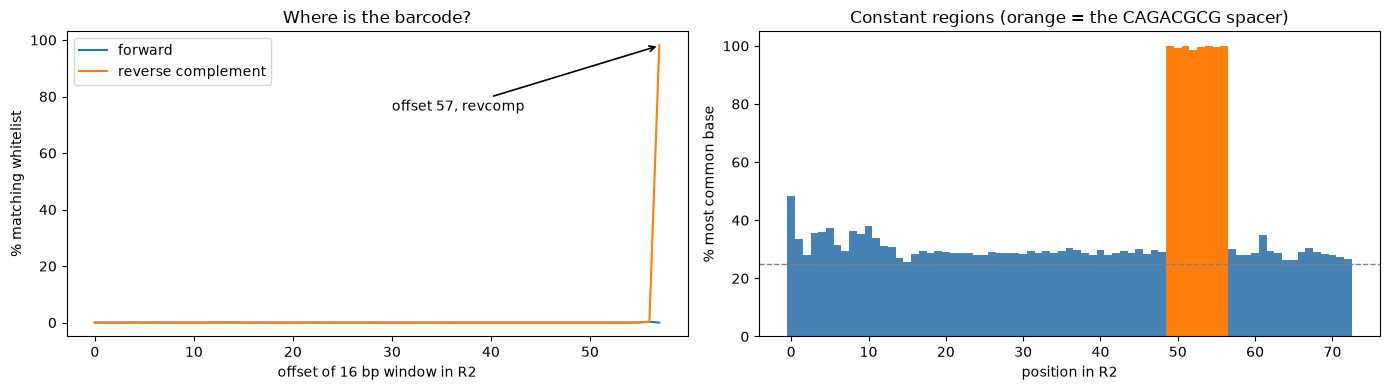

consensus at positions 49-56: 'CAGACGCG'


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(scan.offset, scan.forward * 100, label="forward", lw=1.5)
ax.plot(scan.offset, scan.revcomp * 100, label="reverse complement", lw=1.5)
ax.set(xlabel="offset of 16 bp window in R2", ylabel="% matching whitelist",
       title="Where is the barcode?")
ax.legend()
ax.annotate("offset 57, revcomp", xy=(57, 98), xytext=(30, 75),
            arrowprops=dict(arrowstyle="->", lw=1.2))

# Base composition -- a constant region shows up as ~100% one base.
ax = axes[1]
consensus = []
for pos in range(len(r2_seqs[0])):
    c = Counter(s[pos] for s in r2_seqs)
    consensus.append(c.most_common(1)[0][1] / len(r2_seqs))
ax.bar(range(len(consensus)), [c * 100 for c in consensus], width=1.0,
       color=["tab:orange" if 49 <= i < 57 else "steelblue" for i in range(len(consensus))])
ax.axhline(25, ls="--", c="grey", lw=1)
ax.set(xlabel="position in R2", ylabel="% most common base",
       title="Constant regions (orange = the CAGACGCG spacer)", ylim=(0, 105))

plt.tight_layout(); plt.show()

spacer = "".join(Counter(s[p] for s in r2_seqs).most_common(1)[0][0] for p in range(49, 57))
print(f"consensus at positions 49-56: {spacer!r}")

In [4]:
# The layout must hold for BOTH samples, not just the one we looked at first.
rows = []
for f in sorted(IN_ATAC.glob("*_R2.fastq.gz")):
    seqs = read_seqs(f, 3000)
    rows.append({
        "file": f.name,
        "read_len": len(seqs[0]),
        "uniform_len": len({len(s) for s in seqs}) == 1,
        "spacer CAGACGCG @49": f"{sum(s[49:57] == 'CAGACGCG' for s in seqs) / len(seqs):.1%}",
        "barcode revcomp @57": f"{sum(revcomp(s[57:73]) in ATAC_BC for s in seqs) / len(seqs):.1%}",
        "barcode forward @57": f"{sum(s[57:73] in ATAC_BC for s in seqs) / len(seqs):.1%}",
    })
display(pd.DataFrame(rows).set_index("file"))

,read_len,uniform_len,spacer CAGACGCG @49,barcode revcomp @57,barcode forward @57
file,,,,,
SI-NA-E10_L01_R2.fastq.gz,73,True,98.3%,98.2%,0.0%
SI-NA-E11_L01_R2.fastq.gz,73,True,97.0%,98.2%,0.0%


## 2. Why all three files need identical read names

MGI writes read names with a trailing `/1` or `/2`:

```
@E250172652L1C001R00100002708/1     <- in R1
@E250172652L1C001R00100002708/2     <- in R2
```

This is the old Illumina convention. Modern `bcl2fastq` instead writes the name, then a space,
then a comment: `@A00228:279:HFWFVDSXX:1:1101:1000:1000 1:N:0:ATCACG`. The distinction is not
cosmetic. Cell Ranger compares read names across files like this
(`cellranger-arc-2.2.0/lib/python/tenkit/fasta.py`, line 215):

```python
if name1.split()[0] != name2.split()[0]:
    raise FastqParseError(... "Read 1 and Read 2 header prefixes are mismatched" ...)
```

`split()` breaks on whitespace. With the bcl2fastq convention the `/1`-equivalent information
lives *after* a space, so `split()[0]` is identical across files and the check passes. With the
MGI convention there is no space, so `split()[0]` keeps the `/1` and `/2`, the two differ, and
parsing fails.

So the splitter strips the trailing `/N` and writes the **same** name into all three files.

A second, subtler point: `tenkit/lane.py` also tries to parse read names to recover flowcell,
tile and x/y coordinates, used for estimating optical duplicates. Its regex expects the
Illumina colon-delimited form, and `extract_read_position` returns `None` when the name does
not match. MGI names will not match either way — before or after our edit — so we lose nothing
by rewriting them. It does mean tile-based diagnostics will be unavailable for this run, which
is expected rather than a symptom of something we broke.

## 3. The transformation

Small enough to state as one pure function. Two details are easy to get wrong:

* **The quality string must be reversed alongside the sequence.** When you reverse-complement
  a 16 bp barcode, the base that was last becomes first — so its quality score has to move
  with it. Reverse-complementing the sequence but leaving the quality untouched produces a file
  that is *structurally* valid and silently wrong, which is the worst kind of bug. Nothing
  downstream would flag it.
* **Complement, then reverse.** `translate()` then `[::-1]`. Doing only one of the two is the
  classic slip.

`bytes.translate` and slicing are C-speed, which is what makes a pure-Python implementation
fast enough to be worth keeping readable.

In [5]:
COMPLEMENT = bytes.maketrans(b"ACGTNacgtn", b"TGCANtgcan")
GENOMIC_END, SPACER_START, SPACER_END, BC_START, BC_END = 49, 49, 57, 57, 73

def split_record(name: bytes, r1_seq: bytes, r1_qual: bytes,
                 r2_seq: bytes, r2_qual: bytes) -> dict[str, tuple[bytes, bytes, bytes]]:
    """One MGI read pair -> the three records Cell Ranger ARC wants."""
    if len(name) > 2 and name[-2] == 0x2F:      # ord('/')
        name = name[:-2]
    barcode = r2_seq[BC_START:BC_END].translate(COMPLEMENT)[::-1]
    bc_qual = r2_qual[BC_START:BC_END][::-1]    # reversed, NOT complemented
    return {
        "R1": (name, r1_seq, r1_qual),
        "R2": (name, barcode, bc_qual),
        "R3": (name, r2_seq[:GENOMIC_END], r2_qual[:GENOMIC_END]),
    }


# --- tests on a hand-built record where we know the answer -------------------
bc_true = b"AAACAGCCAAACAACA"                      # a real whitelist barcode (GEX list order)
bc_ondisk = bc_true.translate(COMPLEMENT)[::-1]    # how it appears in R2
r2 = b"G" * 49 + b"CAGACGCG" + bc_ondisk
r2q = bytes(range(35, 35 + 49)) + b"IIIIIIII" + bytes(range(60, 76))
out = split_record(b"@READ/2", b"A" * 50, b"F" * 50, r2, r2q)

assert out["R1"][0] == out["R2"][0] == out["R3"][0] == b"@READ", "headers must be identical"
assert out["R2"][1] == bc_true, "barcode not recovered"
assert out["R2"][2] == r2q[57:73][::-1], "barcode quality not reversed"
assert out["R3"][1] == b"G" * 49 and out["R3"][2] == r2q[:49], "R3 must be R2[0:49]"
assert all(len(s) == len(q) for _n, s, q in out.values()), "seq/qual lengths must agree"
assert len(out["R2"][1]) == 16 and len(out["R3"][1]) == 49

# The reversal is not optional -- show what skipping it would cost.
naive = r2[BC_START:BC_END].translate(COMPLEMENT)   # complement without reversing
print("complement only (wrong):", naive.decode(), "-> in whitelist:",
      naive.decode() in ATAC_BC)
print("complement + reverse    :", out["R2"][1].decode(), "-> in whitelist:",
      out["R2"][1].decode() in load_whitelist(GEX_WHITELIST))
print("\nall assertions passed")

complement only (wrong): ACAACAAACCGACAAA -> in whitelist: False


complement + reverse    : AAACAGCCAAACAACA -> in whitelist: True

all assertions passed


## 4. Run it over real data

`scripts/split_atac.py` is the same logic wrapped in a streaming pipeline: a `zcat` process per
input, this transform in the middle, and a `gzip` process per output. That shape matters — it
puts decompression, transformation and compression on separate cores, so on a 4-core laptop the
work overlaps instead of queueing.

It validates as it goes. Over the first 100,000 reads it measures the whitelist match rate and
aborts if it falls below `--min-match`. A wrong offset therefore costs you three seconds, not
three hours.

`--limit` caps the number of reads, which is what makes the run below a test rather than the
real thing.

In [6]:
import shutil
if SCRATCH.exists():
    shutil.rmtree(SCRATCH)

cmd = [
    sys.executable, str(PROJECT / "scripts/split_atac.py"),
    "--r1", str(IN_ATAC / "SI-NA-E10_L01_R1.fastq.gz"),
    "--r2", str(IN_ATAC / "SI-NA-E10_L01_R2.fastq.gz"),
    "--out-dir", str(SCRATCH),
    "--sample", "5wks_f_ATAC",
    "--limit", "200000",
]
print(" ".join(cmd), "\n")
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stderr)

/home/supermepsipax/Code/cellranger/.venv/bin/python /home/supermepsipax/Code/cellranger/scripts/split_atac.py --r1 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E10_L01_R1.fastq.gz --r2 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E10_L01_R2.fastq.gz --out-dir /home/supermepsipax/Code/cellranger/data/atac_split_test --sample 5wks_f_ATAC --limit 200000 



[10:06:42] loading ATAC whitelist ...
[10:06:43] in  R1 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E10_L01_R1.fastq.gz
[10:06:43] in  R2 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E10_L01_R2.fastq.gz
[10:06:43] out R1 /home/supermepsipax/Code/cellranger/data/atac_split_test/5wks_f_ATAC_S1_L001_R1_001.fastq.gz
[10:06:43] out R2 /home/supermepsipax/Code/cellranger/data/atac_split_test/5wks_f_ATAC_S1_L001_R2_001.fastq.gz
[10:06:43] out R3 /home/supermepsipax/Code/cellranger/data/atac_split_test/5wks_f_ATAC_S1_L001_R3_001.fastq.gz
[10:06:43] compressor: gzip -3
[10:06:43] validation over first 100,000 reads: barcode whitelist 97.8%, spacer 96.9%

[10:06:44] done: 200,000 reads in 0.0 min (129k reads/s)
  barcode whitelist match (first 100,000): 97.8%
  R1: /home/supermepsipax/Code/cellranger/data/atac_split_test/5wks_f_ATAC_S1_L001_R1_001.fastq.gz  (0.0 GB)
  R2: /home/supermepsipax/Code/cellranger/data/atac_split_test/5wks_f_ATAC_S1_L001_R2_001.

## 5. Prove it, by going backwards

The whitelist match rate says the barcodes are plausible. It does *not* say the genomic reads
survived intact, that quality strings stayed aligned to their bases, or that record *i* of the
output corresponds to record *i* of the input.

So we check the only way that actually settles it: read the original two files and the three
new ones side by side, and assert that the outputs reconstruct the inputs exactly. This is
deliberately written against the original slice offsets rather than by calling `split_record`
again — re-using the function under test would just prove it agrees with itself.

In [7]:
def records(path: Path, n: int) -> list[tuple[bytes, bytes, bytes]]:
    out = []
    with gzip.open(path, "rb") as fh:
        it = iter(fh)
        for h in it:
            s = next(it); next(it); q = next(it)
            out.append((h.strip(), s.strip(), q.strip()))
            if len(out) >= n:
                break
    return out

N = 200_000
in_r1 = records(IN_ATAC / "SI-NA-E10_L01_R1.fastq.gz", N)
in_r2 = records(IN_ATAC / "SI-NA-E10_L01_R2.fastq.gz", N)
o = {r: records(SCRATCH / f"5wks_f_ATAC_S1_L001_{r}_001.fastq.gz", N) for r in ("R1", "R2", "R3")}

assert len(o["R1"]) == len(o["R2"]) == len(o["R3"]) == N, "output record counts differ"

failures = []
for i in range(N):
    (h1, s1, q1), (h2, s2, q2), (h3, s3, q3) = o["R1"][i], o["R2"][i], o["R3"][i]
    src1, src2 = in_r1[i], in_r2[i]
    if not h1 == h2 == h3:                      failures.append((i, "headers differ")); break
    if h1 != src1[0][:-2]:                      failures.append((i, "header != original minus /1")); break
    if (s1, q1) != (src1[1], src1[2]):          failures.append((i, "R1 not passed through")); break
    if (s3, q3) != (src2[1][:49], src2[2][:49]):failures.append((i, "R3 != R2[0:49]")); break
    if s2 != src2[1][57:73].translate(COMPLEMENT)[::-1]:
                                                failures.append((i, "R2 seq wrong")); break
    if q2 != src2[2][57:73][::-1]:              failures.append((i, "R2 qual wrong")); break

print(f"round-trip checked {N:,} reads x 3 files")
if failures:
    print("FAILED:", failures[:3])
else:
    print("PASSED -- outputs reconstruct the inputs exactly\n")
    print(f"  header : {o['R1'][0][0].decode()}")
    print(f"  R1     : {o['R1'][0][1][:24].decode()}...  ({len(o['R1'][0][1])} bp)")
    print(f"  R2     : {o['R2'][0][1].decode()}          ({len(o['R2'][0][1])} bp)  <- barcode")
    print(f"  R3     : {o['R3'][0][1][:24].decode()}...  ({len(o['R3'][0][1])} bp)")

round-trip checked 200,000 reads x 3 files
PASSED -- outputs reconstruct the inputs exactly

  header : @E250172652L1C001R00100002708
  R1     : GCATCAACCTTTGATGAATTAAGT...  (50 bp)
  R2     : GGTTAGTAGTAAAGGG          (16 bp)  <- barcode
  R3     : GTAAAGGTGAACTTCAGAAAGAGT...  (49 bp)


## 6. Preflight

The round-trip proves the transformation is faithful. Preflight (from notebook 01, now in
`scripts/arc_qc.py`) asks the different question of whether Cell Ranger ARC will accept the
result: filenames, required reads, lengths, and barcodes in the expected orientation.

In [8]:
preflight(SCRATCH, "Chromatin Accessibility")


PREFLIGHT: /home/supermepsipax/Code/cellranger/data/atac_split_test  [Chromatin Accessibility]
  barcode  5wks_f_ATAC_S1_L001_R2_001.fastq.gz: 'as-is' (expected) = 98.3%; best = 'as-is' at 98.3%

  RESULT: READY


True

## 7. What the full run costs

Measured on this machine, the pipeline sustains about **125,000 reads/second**, holding up even
when reading from and writing to the same external HDD. Read counts come from the `mgikit`
`sample_stats` report — each 10x `SI-NA-*` index is a set of four oligos, so the per-sample
total is the sum of its four rows.

Two caveats on the estimate below. It assumes sustained throughput; a spinning disk servicing
concurrent reads and writes can degrade over hours in a way a two-minute benchmark will not
reveal. And the two samples are best run **sequentially** — running them in parallel on four
cores would oversubscribe the CPU and force the drive to seek between two read streams and six
write streams.

In [9]:
READS_PER_SEC = 125_000
BYTES_PER_READ = 358e6 / 5e6      # measured: 358 MB of gzip output per 5M reads

samples = {
    "5wks_f": {"idx": "SI-NA-E10", "reads": 285449569 + 233419301 + 377152084 + 288269104},
    "9wks_f": {"idx": "SI-NA-E11", "reads": 480262553 + 168803716 + 278774668 + 361012710},
}

rows = []
for name, s in samples.items():
    hrs = s["reads"] / READS_PER_SEC / 3600
    rows.append({
        "sample": name, "index": s["idx"],
        "read pairs": f"{s['reads']:,}",
        "est. hours": f"{hrs:.1f}",
        "est. output": f"{s['reads'] * BYTES_PER_READ / 1e9:.0f} GB",
    })
df = pd.DataFrame(rows)
display(df)

total_h = sum(s["reads"] for s in samples.values()) / READS_PER_SEC / 3600
total_gb = sum(s["reads"] for s in samples.values()) * BYTES_PER_READ / 1e9
free_gb = shutil.disk_usage(DRIVE).free / 1e9
print(f"total sequential runtime : ~{total_h:.1f} h")
print(f"total output             : ~{total_gb:.0f} GB")
print(f"free on {DRIVE}: {free_gb:,.0f} GB  -> {'OK' if free_gb > total_gb * 1.2 else 'TIGHT'}")

,sample,index,read pairs,est. hours,est. output
0,5wks_f,SI-NA-E10,"1,184,290,058",2.6,85 GB
1,9wks_f,SI-NA-E11,"1,288,853,647",2.9,92 GB


total sequential runtime : ~5.5 h
total output             : ~177 GB
free on /media/supermepsipax/Tristan_Backup: 2,776 GB  -> OK


## 8. Launching the full run

Run this from a terminal, **not** from a notebook cell — it takes hours and a closed kernel
would kill it. `nohup` detaches it from the terminal so it survives logout.

```bash
cd /home/supermepsipax/Code/cellranger
D=/media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC
OUT=/media/supermepsipax/Tristan_Backup/arc_ready
mkdir -p $OUT                     # the log redirect needs this to exist first

nohup uv run python scripts/split_atac.py \
  --r1 $D/SI-NA-E10_L01_R1.fastq.gz --r2 $D/SI-NA-E10_L01_R2.fastq.gz \
  --out-dir $OUT/atac/5wks_f --sample 5wks_f_ATAC \
  > $OUT/5wks_f.log 2>&1 &

# wait for that to finish, then:
nohup uv run python scripts/split_atac.py \
  --r1 $D/SI-NA-E11_L01_R1.fastq.gz --r2 $D/SI-NA-E11_L01_R2.fastq.gz \
  --out-dir $OUT/atac/9wks_f --sample 9wks_f_ATAC \
  > $OUT/9wks_f.log 2>&1 &
```

Watch it with `tail -f $OUT/5wks_f.log`. Progress lines report cumulative reads, current rate
and elapsed minutes every 5M reads.

**The line that matters is the first one.** Within a few seconds you get:

```
[HH:MM:SS] validation over first 100,000 reads: barcode whitelist 97.8%, spacer 96.9%
```

If that says ~98%, the offsets are right and the remaining hours are just throughput. If it
prints an abort message instead, stop and re-run section 1 against the file in question.

**Installing `pigz` would speed this up** — the script uses it automatically when present,
parallelising the compression that is otherwise the bottleneck:

```bash
sudo apt install pigz
```

A note on safety: the script refuses to start if any output file already exists, so an
interrupted run will not be silently half-overwritten. If you need to restart, delete the
partial output directory first.

In [10]:
# Convenience: emit the exact commands for your current paths.
print(f"mkdir -p {ARC_READY}\n")
for name, s in samples.items():
    print(f"# ---- {name} ({s['idx']}) ----")
    print(f"""nohup uv run python scripts/split_atac.py \\
  --r1 {IN_ATAC}/{s['idx']}_L01_R1.fastq.gz \\
  --r2 {IN_ATAC}/{s['idx']}_L01_R2.fastq.gz \\
  --out-dir {ARC_READY}/atac/{name} \\
  --sample {name}_ATAC \\
  > {ARC_READY}/{name}_atac.log 2>&1 &
""")

mkdir -p /media/supermepsipax/Tristan_Backup/arc_ready

# ---- 5wks_f (SI-NA-E10) ----
nohup uv run python scripts/split_atac.py \
  --r1 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E10_L01_R1.fastq.gz \
  --r2 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E10_L01_R2.fastq.gz \
  --out-dir /media/supermepsipax/Tristan_Backup/arc_ready/atac/5wks_f \
  --sample 5wks_f_ATAC \
  > /media/supermepsipax/Tristan_Backup/arc_ready/5wks_f_atac.log 2>&1 &

# ---- 9wks_f (SI-NA-E11) ----
nohup uv run python scripts/split_atac.py \
  --r1 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E11_L01_R1.fastq.gz \
  --r2 /media/supermepsipax/Tristan_Backup/transfer/MGI_Outs/ATAC/SI-NA-E11_L01_R2.fastq.gz \
  --out-dir /media/supermepsipax/Tristan_Backup/arc_ready/atac/9wks_f \
  --sample 9wks_f_ATAC \
  > /media/supermepsipax/Tristan_Backup/arc_ready/9wks_f_atac.log 2>&1 &



## 9. The GEX side, and `libraries.csv`

The RNA reads need no restructuring — 28 bp and 90 bp, exactly to spec. But they carry the
**same `/1` and `/2` header suffixes**, so by the argument in section 2 they still need the
suffix stripped. That is a one-line stream edit, and `mawk` is fast enough that the job is
bounded by gzip:

```bash
zcat in.fastq.gz | mawk 'NR%4==1{sub(/\/[12]$/,"")}1' | gzip -3 > out.fastq.gz
```

Two further things to fix while staging the GEX files, both noted when we surveyed the drive:

* `SI-TT-G9_L04_R1/R2.fastq.gz` are sitting in `RNA/L03/` rather than `RNA/L04/`. Consolidating
  every lane for a library into one directory makes this moot — but check the lane numbers in
  the filenames as you go, because the directory is not to be trusted.
* Sample identity comes from `Sample_sheet_250312_RNA_V2_corrected_label.csv`. The uncorrected
  sheet labels the RNA libraries `..._ATAC_v2`.

The pairing to carry into `libraries.csv`:

| Biological sample | ATAC index | GEX index |
|---|---|---|
| `5wks_f` | `SI-NA-E10` | `SI-TT-G9` |
| `9wks_f` | `SI-NA-E11` | `SI-TT-B9` |

Note this is **one `cellranger-arc count` run per biological sample** — each run takes the ATAC
and GEX libraries for that one sample. Two samples means two runs and two `libraries.csv`
files, not one combined run.

```
fastqs,sample,library_type
/media/supermepsipax/Tristan_Backup/arc_ready/atac/5wks_f,5wks_f_ATAC,Chromatin Accessibility
/media/supermepsipax/Tristan_Backup/arc_ready/gex/5wks_f,5wks_f_GEX,Gene Expression
```

### Before you start the count

The reference at `transfer/aPleWal1_split_clean_v3` is already built and its
`mkref_version` of `cellranger-arc-2.0.2` is accepted by 2.2.0. But its STAR index is 104 GB
and has to be resident in RAM. **This laptop has 11 GB.** The conversion in this notebook runs
fine here; `cellranger-arc count` will not. Budget for a machine with at least 128 GB of RAM
before the alignment step.